# Bagging Regressor with Decision Trees

__INDEX__  

1. [Bagging with Decision Trees](#bagging_dt) <br>
    1.1. [About Bagging and Decision Trees](#about) <br>
    1.2. [BaggingRegressor with DecisionTreeRegressor in Scikit-learn](#scikit) <br>
    1.3. [Why Bagging + Decision Trees?](#project) <br>
2. [Setup and Data Preparation](#setup)  
3. [Model Selection Experiments](#expruns) <br>
   3.1. [Full Feature Set Experiment](#allfeat) <br>
    3.2. [Excluding `previousOwners`+ Log(Price)](#noprevown) <br>
    3.3. [Feature Engineering: Ablations and Additions](#feateng) <br>
        3.3.1 [Original+ Feature engineered features + Log(price)](#featengnosel) <br>
        3.3.2 [Original + Feature engineered features + Log(price)+ 65% FS](#featengsel) <br>
        3.3.3 [Age + Excluding `previousOwners`+ Log(Price)](#agenofs) <br>
        3.3.4 [Age + Excluding `previousOwners`+ Log(Price) + 80% FS](#agefs) <br>
   
4. [Conclusions](#conclusions)  
   4.1 [Visualizations](#visualization) <br>
   4.2 [Results Obtained and Overall Performance Discussion](#results)


## 1. Bagging with Decision Trees <a id="bagging_dt"></a>

### 1.1. About Bagging and Decision Trees <a id="about"></a>

Bagging (Bootstrap Aggregating) is an ensemble technique that improves the stability and accuracy of high-variance models, like decision trees, by reducing their sensitivity to small changes in training data. It works by training multiple models on different random samples (bootstrap samples) of the training data and aggregating their predictions (averaging for regression tasks).

Decision Trees are ideal base estimators for Bagging because they capture complex non-linear relationships but are highly prone to overfitting. Bagging addresses this issue by averaging the outputs of several trees, which reduces variance without significantly increasing bias.

Thus, using Bagging with Decision Trees creates a robust model that balances expressiveness, due to the tree structure, and stability, due to ensemble averaging.

### 1.2. BaggingRegressor with DecisionTreeRegressor in Scikit-learn <a id="scikit"></a>

Scikit-learn offers a flexible implementation of Bagging through the BaggingRegressor class, which allows any regressor to be used as the base estimator. In this project, we combine BaggingRegressor with DecisionTreeRegressor to explicitly control both ensemble-level and tree-level complexity.

At the ensemble level, we tune parameters such as:

    - the number of trees (n_estimators);
    - the proportion of samples used per tree (max_samples);
    - the proportion of features considered by each estimator (max_features).

At the base tree level, we control:

    - the maximum depth of each tree;
    - the minimum number of samples required to split a node;
    - the minimum number of samples in leaf nodes.

Bagging trains all trees independently and in parallel, which improves training stability and reduces sensitivity to noise. Furthermore, this setup allows us to explicitly study the bias–variance trade-off by adjusting tree depth and ensemble size.

### 1.3. Why Bagging + Decision Trees? <a id="project"></a>

We include Bagging with Decision Trees as a core model in our experimental framework for several reasons:
- **Non-linearity:** Decision Trees can capture complex feature interactions and non-monotonic effects, which are common in vehicle pricing.

- **Overfitting Control:** Bagging helps reduce overfitting without restricting individual trees too much. Instead of simplifying trees early, we rely on the ensemble to stabilize predictions.

- **Interpretability:** Bagging is easier to interpret in terms of the bias-variance trade-off compared to more complex models like Gradient Boosting. It’s less sensitive to noise, making it a good choice when data has inconsistencies, outliers, or unknown factors.

- **Benchmarking:** Bagging provides a strong reference to compare more complex models and see if they offer real improvements over a well-regularized ensemble of decision trees.

## 2. Setup and Preparation <a id="setup"></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeRegressor
import random
import logging
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
)
from sklearn.ensemble import RandomForestRegressor

In [ ]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

def get_random_configs(n_iter: int):
    configs = []
    keys = list(param_distributions.keys())

    for i in range(n_iter):
        params = {k: random.choice(list(param_distributions[k])) for k in keys}

        name = (
            f"R{i}"
            f"_n{params['n_estimators']}"
            f"_ms{params['max_samples']}"
            f"_mf{params['max_features']}"
            f"_d{params['tree_max_depth']}"
            f"_leaf{params['tree_min_samples_leaf']}"
            f"_split{params['tree_min_samples_split']}"
        )

        configs.append((name, params))

    return configs

In [ ]:
%run 05_0.1_visualization_helpers.ipynb  

c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# lists previously defined in 05_0_preproc_helpers.ipynb
numeric_features = num_feat                      # ['year', 'mileage', ...]
categorical_features = cat_feat                  # ['Brand', 'model', 'transmission', 'fuelType']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 5 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Model Selection Experiments (Random Search and 8-Fold CV)  <a id="expruns"></a>

### 3.1. Full Feature Set Experiment <a id="allfeat"></a>

In [ ]:
# K-FOLD CROSS-VALIDATION

# The data is shuffled before splitting to ensure that, at least theoretically, each fold is more balanced and
# representative of the full dataset distribution.
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)



# HYPERPARAMETER SPACE FOR RANDOM SEARCH

# Each random configuration will sample exactly one value from each list below.
# The parameters are divided into:
#  - ensemble-level (Bagging)
#  - base estimator-level (Decision Tree)

param_distributions = {

    # Bagging (ensemble-level)
    
    "n_estimators": [400,1000,1200], # Number of trees in the ensemble
    # Higher values usually improve stability but increase training time.

    "max_samples": [0.5, 1.0], # Fraction of samples used to train each tree
    # Values < 1.0 increase diversity between estimators.

    "max_features": [0.8, 0.9], # Fraction of features used by each estimator
    # This helps reduce correlation between trees.

    
    # Decision Tree (base model)
    
    "tree_max_depth": [15, 25], # Maximum depth of each decision tree

    "tree_min_samples_leaf": [1, 5], # Minimum number of samples required at a leaf node
    # Larger values increase regularization.

    "tree_min_samples_split": [10, 30] # Minimum number of samples required to split an internal node
}


N_RANDOM_CONFIGS = 20 # Number of random configurations to evaluate
# This is intentionally small, as this run is intended to provide baseline and comparative results.


# RANDOM SAMPLER

# Randomly samples N_RANDOM_CONFIGS combinations from the hyperparameter space defined above
sampler = ParameterSampler(
    param_distributions,
    n_iter=N_RANDOM_CONFIGS,
    random_state=RANDOM_STATE
)

# List to store results for each configuration
search_results = []

# Track the best configuration according to validation RMSE
best_rmse = np.inf
best_config = None



# LOGGING SETUP

# All logs are written both to the console and to a file for reproducibility and later inspection.
log_path = "Bagging_DT_complete_random_search.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    # Helper logging function
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    # Log header
    log("# =============================")
    log("# START OF BAGGING + DECISION TREE SEARCH")
    log("# DETAILED METRICS: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    
    # RANDOM SEARCH LOOP
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Containers for fold-level metrics
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        
        # K-FOLD CROSS-VALIDATION
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            # Split data into training and validation sets
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            
            # PREPROCESSING PIPELINE
        
            # All transformations are fit ONLY on the training data and then applied to both training and validation sets.

            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)


            # FEATURE ENCODING

            # High-cardinality features use target encoding,
            # low-cardinality features use one-hot encoding.
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # Combine numerical and encoded categorical features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            
            # FEATURE SCALING
            
            # Although tree-based models do not strictly require scaling, we apply StandardScaler for numerical stability and
            # consistency across models.
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_final)
            X_val_scaled   = scaler.transform(X_val_final)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            
            # MODEL DEFINITION
            
            base_tree = DecisionTreeRegressor(
                max_depth=params["tree_max_depth"],
                min_samples_leaf=params["tree_min_samples_leaf"],
                min_samples_split=params["tree_min_samples_split"],
                random_state=RANDOM_STATE
            )

            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=params["max_samples"],
                max_features=params["max_features"],
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            # Train the model
            model.fit(X_train_scaled, y_train)

            
            # PREDICTIONS

            y_pred_train = model.predict(X_train_scaled)
            y_pred_val   = model.predict(X_val_scaled)


            
            # METRICS
            
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr)
            fold_rmses_tr.append(rmse_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_maes_val.append(mae_val)
            fold_rmses_val.append(rmse_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        
        # AGGREGATED RESULTS
        
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")



# FINAL RESULTS

results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["n_estimators", "max_samples", "max_features", "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF BAGGING + DECISION TREE SEARCH
# DETAILED METRICS: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: Bagging_DT_complete_random_search.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'tree_min_samples_split': 10, 'tree_min_samples_leaf': 1, 'tree_max_depth': 15, 'n_estimators': 1000, 'max_samples': 1.0, 'max_features': 0.9}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'year', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9700 | RMSE: 1696 | MAE: 1058 | Bias: -1.4
  > [VAL]   R2: 0.9513 | RMSE: 2107 | MAE: 1322 | Bias: -29.2

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9697 | RMSE: 1694 | MAE: 1045 | Bias: -0.6
  > [VAL]   R2: 0.9467 | RMSE: 2246 | MAE: 1329 | Bias: 16.8

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9

,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split,val_rmse,val_mae,val_r2,train_r2,val_bias
0,1000,1.0,0.9,15,1,10,2253.138512,1319.006111,0.946329,0.969942,1.446005
16,1000,0.5,0.8,25,1,10,2301.912267,1322.958372,0.943973,0.964801,-4.022227
13,400,0.5,0.8,25,1,10,2303.450477,1325.364754,0.943902,0.964954,-3.537443
3,1200,1.0,0.9,25,5,10,2319.869676,1320.379370,0.943077,0.964434,4.450156
11,400,1.0,0.8,25,5,10,2323.274982,1329.992345,0.942912,0.963711,4.073674



Best Config found:
{'tree_min_samples_split': 10, 'tree_min_samples_leaf': 1, 'tree_max_depth': 15, 'n_estimators': 1000, 'max_samples': 1.0, 'max_features': 0.9}


### 3.2. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) <a id="noprevown"></a>

In [ ]:
# K-FOLD CROSS-VALIDATION

# The data is shuffled before splitting to ensure that, at least theoretically, each fold is more balanced and
# representative of the full dataset distribution.
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]
DROP_FROM_MODEL = ["previousOwners"]

# HYPERPARAMETER SPACE FOR RANDOM SEARCH

# Each random configuration will sample exactly one value from each list below.
# The parameters are divided into:
#  - ensemble-level (Bagging)
#  - base estimator-level (Decision Tree)
param_distributions = {

    # Bagging (ensemble-level)
    
    "n_estimators": [400, 600,1000], # Number of trees in the ensemble

    "max_samples": [0.5, 1.0], # Fraction of samples used to train each tree

    "max_features": [0.6, 0.8, 0.9], # Fraction of features used by each estimator

    
    # Decision Tree (base model)
    
    "tree_max_depth": [15, 20, 25], # Maximum depth of each decision tree

    "tree_min_samples_leaf": [1, 5, 10], # Minimum number of samples required at a leaf node

    "tree_min_samples_split": [10, 30, 50] # Minimum number of samples required to split an internal node
}

# Number of random configurations to evaluate.
# This is intentionally small, as this run is intended to provide baseline and comparative results.
N_RANDOM_CONFIGS = 20



# RANDOM SAMPLER

# Randomly samples N_RANDOM_CONFIGS combinations from the hyperparameter space defined above.
sampler = ParameterSampler(
    param_distributions,
    n_iter=N_RANDOM_CONFIGS,
    random_state=RANDOM_STATE
)

# List to store results for each configuration
search_results = []

# Track the best configuration according to validation RMSE
best_rmse = np.inf
best_config = None



# LOGGING SETUP

# All logs are written both to the console and to a file for reproducibility and later inspection.
log_path = "Bagging_DT_noprev_log_price.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    # Helper logging function
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    # Log header
    log("# =============================")
    log("# START OF BAGGING + DECISION TREE SEARCH")
    log("# DETAILED METRICS: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    
    # RANDOM SEARCH LOOP
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Containers for fold-level metrics
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        
        # K-FOLD CROSS-VALIDATION
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            # Split data into training and validation sets
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            y_train_log = np.log1p(y_train)
            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            
            # PREPROCESSING PIPELINE
        
            # All transformations are fit ONLY on the training data and then applied to both training and validation sets.

            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # FEATURE ENCODING

            # High-cardinality features use target encoding,
            # low-cardinality features use one-hot encoding.
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # Combine numerical and encoded categorical features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            
            # FEATURE SCALING
            
            # Although tree-based models do not strictly require scaling,
            # we apply StandardScaler for numerical stability and
            # consistency across models.
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_final)
            X_val_scaled   = scaler.transform(X_val_final)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            
            # MODEL DEFINITION
            
            base_tree = DecisionTreeRegressor(
                max_depth=params["tree_max_depth"],
                min_samples_leaf=params["tree_min_samples_leaf"],
                min_samples_split=params["tree_min_samples_split"],
                random_state=RANDOM_STATE
            )

            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=params["max_samples"],
                max_features=params["max_features"],
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            # Train the model
            model.fit(X_train_scaled, y_train_log)

            
            # PREDICTIONS

            y_pred_train_log = model.predict(X_train_scaled)
            y_pred_val_log   = model.predict(X_val_scaled)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)



            
            # METRICS
            
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr)
            fold_rmses_tr.append(rmse_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_maes_val.append(mae_val)
            fold_rmses_val.append(rmse_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        
        # AGGREGATED RESULTS
        
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")



# FINAL RESULTS

results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["n_estimators", "max_samples", "max_features", "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF BAGGING + DECISION TREE SEARCH
# DETAILED METRICS: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: Bagging_DT_noprev_log_price.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'tree_min_samples_split': 10, 'tree_min_samples_leaf': 10, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 1.0, 'max_features': 0.9}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'year', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9438 | RMSE: 2320 | MAE: 1228 | Bias: 196.9
  > [VAL]   R2: 0.9400 | RMSE: 2338 | MAE: 1403 | Bias: 179.0

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9430 | RMSE: 2326 | MAE: 1229 | Bias: 198.7
  > [VAL]   R2: 0.9265 | RMSE: 2636 | MAE: 1409 | Bias: 240.4

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9460

,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split,val_rmse,val_mae,val_r2,train_r2,val_bias
18,400,0.5,0.9,20,1,10,2398.450536,1323.934827,0.939092,0.960686,200.333790
7,1000,0.5,0.8,20,1,10,2421.805163,1329.788696,0.937910,0.959003,235.530058
12,1000,1.0,0.9,25,5,10,2429.194857,1327.159463,0.937508,0.960134,196.561050
1,400,1.0,0.8,25,1,30,2477.684755,1358.049799,0.935023,0.953909,239.222214
19,400,1.0,0.6,20,1,10,2568.316325,1415.767419,0.930237,0.958256,365.917641



Best Config found:
{'tree_min_samples_split': 10, 'tree_min_samples_leaf': 1, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 0.5, 'max_features': 0.9}


### 3.3. Feature Engineering: Ablations and Additions <a id="feateng"></a>

#### 3.3.1. Original and Engineered Features (No Feature Selection) with Log-Transformed Target (price) <a id="featengnosel"></a>

In [ ]:
N_ITER = 35
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year", "previousOwners"]

# Random seed for reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# 0.1) LOGGING
LOG_FILE = "bagging_fe_no_fs_iter10.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | BAGGING_DT | NO_FEATURE_SELECTION")


# 0.2) RANDOM SEARCH
param_distributions = {

    # Bagging (ensemble-level)
    
    # Number of trees in the ensemble.
    "n_estimators": [400, 600,1000],

    # Fraction of samples used to train each tree.
    "max_samples": [0.5, 1.0],

    # Fraction of features used by each estimator.
    "max_features": [0.6, 0.8, 0.9],

    
    # Decision Tree (base model)
    
    # Maximum depth of each decision tree.
    "tree_max_depth": [15, 20, 25],

    # Minimum number of samples required at a leaf node.
    "tree_min_samples_leaf": [1, 5, 10],

    # Minimum number of samples required to split an internal node.
    "tree_min_samples_split": [10, 30, 50]
}



CONFIGS = get_random_configs(N_ITER)


# 1) K-FOLD
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

def _normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, column=col, remove_middle_spaces=True, allow_extra_chars="")
    return df


# 1.3) EVAL OF 1 CONFIG (metrics in €)
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # log transform the target
        y_train_log = np.log1p(y_train)

        # string normalization
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # restrict to base columns only
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # Guardrails - ensure all required columns are present
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] necessary columns missing: {missing}")


        # A) CLEANING
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)


        # B) RESOLVERS
        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # C) FEATURE ENGINEERING
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]


        # D) ENCODING
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        if len(numeric_features_curr) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features_curr] = scaler.fit_transform(X_train_final[numeric_features_curr])
            X_val_final[numeric_features_curr]   = scaler.transform(X_val_final[numeric_features_curr])


        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


        # E) TRAIN (HGB, log target) + PREDICT (euros) [NO FS]
        n_feats = int(X_train_final.shape[1])

        base_tree = DecisionTreeRegressor(
            max_depth=params["tree_max_depth"],
            min_samples_leaf=params["tree_min_samples_leaf"],
            min_samples_split=params["tree_min_samples_split"],
            random_state=RANDOM_STATE
        )

        model = BaggingRegressor(
            estimator=base_tree,
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            max_features=params["max_features"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_train_final, y_train_log)


        pred_tr_log  = model.predict(X_train_final)
        pred_val_log = model.predict(X_val_final)

        pred_tr  = np.expm1(pred_tr_log)   # euros
        pred_val = np.expm1(pred_val_log)  # euros


        # F) METRICS (euros)
        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features": n_feats,

            "train_rmse": rmse(y_train, pred_tr),
            "val_rmse":   rmse(y_val,   pred_val),

            "train_mae": float(mean_absolute_error(y_train, pred_tr)),
            "val_mae":   float(mean_absolute_error(y_val,   pred_val)),

            "train_r2": float(r2_score(y_train, pred_tr)),
            "val_r2":   float(r2_score(y_val,   pred_val)),

            "train_bias": bias(y_train, pred_tr),
            "val_bias":   bias(y_val,   pred_val),
        })

    df_folds = pd.DataFrame(fold_rows)

    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_features": float(df_folds["n_features"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Feats: {out['avg_features']:.0f}"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"Params={params}"
    )

    return out


# 2) RUN ALL CONFIGS
results = []
best_rmse = np.inf
best_row = None

for i, (name, params) in enumerate(CONFIGS):
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    res = eval_one_config(name, params)
    results.append(res)

    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results)


# 3) FINAL RESULTS
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_features",
    "n_estimators", "max_samples", "max_features",
    "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split"
]


display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_results_rmse_no_fs_iter10.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)


-- doing 1/35
   >> [R0_n1000_ms0.5_mf0.6_d25_leaf5_split10] VAL RMSE: 2745.6 | VAL R2: 0.9202 | VAL MAE: 1493.1 | VAL Bias: 363.7 | Feats: 25
   >> [R1_n400_ms0.5_mf0.9_d15_leaf10_split50] VAL RMSE: 2874.8 | VAL R2: 0.9126 | VAL MAE: 1541.2 | VAL Bias: 248.7 | Feats: 25
   >> [R2_n1000_ms0.5_mf0.9_d20_leaf1_split10] VAL RMSE: 2414.7 | VAL R2: 0.9383 | VAL MAE: 1341.1 | VAL Bias: 183.5 | Feats: 25
   >> [R3_n400_ms0.5_mf0.6_d25_leaf10_split10] VAL RMSE: 2934.2 | VAL R2: 0.9090 | VAL MAE: 1573.8 | VAL Bias: 401.9 | Feats: 25
   >> [R4_n1000_ms0.5_mf0.9_d25_leaf10_split50] VAL RMSE: 2871.0 | VAL R2: 0.9128 | VAL MAE: 1536.5 | VAL Bias: 246.8 | Feats: 25

-- doing 6/35
   >> [R5_n600_ms0.5_mf0.8_d25_leaf5_split10] VAL RMSE: 2581.9 | VAL R2: 0.9294 | VAL MAE: 1400.9 | VAL Bias: 233.7 | Feats: 25
   >> [R6_n400_ms1.0_mf0.8_d20_leaf1_split10] VAL RMSE: 2347.5 | VAL R2: 0.9416 | VAL MAE: 1313.1 | VAL Bias: 195.1 | Feats: 25
   >> [R7_n600_ms0.5_mf0.6_d20_leaf1_split30] VAL RMSE: 2770.1 | VAL

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_features,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split
6,R6_n400_ms1.0_mf0.8_d20_leaf1_split10,2347.545538,1313.142253,0.941632,195.076309,1637.208394,906.496366,0.971723,146.420001,25.0,400,1.0,0.8,20,1,10
17,R17_n400_ms1.0_mf0.8_d20_leaf1_split10,2347.545538,1313.142253,0.941632,195.076309,1637.208394,906.496366,0.971723,146.420001,25.0,400,1.0,0.8,20,1,10
16,R16_n1000_ms0.5_mf0.9_d20_leaf1_split10,2414.714660,1341.077636,0.938268,183.465750,1919.152813,1055.990129,0.961148,154.938834,25.0,1000,0.5,0.9,20,1,10
2,R2_n1000_ms0.5_mf0.9_d20_leaf1_split10,2414.714660,1341.077636,0.938268,183.465750,1919.152813,1055.990129,0.961148,154.938834,25.0,1000,0.5,0.9,20,1,10
12,R12_n600_ms1.0_mf0.8_d25_leaf5_split10,2462.288108,1353.156364,0.935796,209.009045,1942.440680,1034.885579,0.960198,172.806913,25.0,600,1.0,0.8,25,5,10
11,R11_n400_ms0.5_mf0.8_d15_leaf1_split10,2473.733262,1384.708988,0.935236,229.140809,2068.467868,1177.248462,0.954869,199.785284,25.0,400,0.5,0.8,15,1,10
19,R19_n1000_ms1.0_mf0.6_d20_leaf1_split10,2503.129367,1401.548778,0.933699,321.280375,1829.860879,1023.777174,0.964678,249.501982,25.0,1000,1.0,0.6,20,1,10
30,R30_n1000_ms1.0_mf0.8_d15_leaf1_split30,2507.220840,1399.991628,0.933472,228.668305,2150.299542,1224.869508,0.951226,202.603971,25.0,1000,1.0,0.8,15,1,30
32,R32_n400_ms1.0_mf0.6_d25_leaf1_split10,2514.030247,1408.857243,0.933112,325.335538,1787.463476,983.649376,0.966296,244.498014,25.0,400,1.0,0.6,25,1,10
23,R23_n1000_ms1.0_mf0.9_d15_leaf5_split30,2559.642385,1411.994137,0.930657,201.630713,2245.380259,1247.095237,0.946818,180.644144,25.0,1000,1.0,0.9,15,5,30


stored at: random_search_fe_results_rmse_no_fs_iter10.csv
log in: bagging_fe_no_fs_iter10.log

- BEST CONFIG (by VAL RMSE)
Best config name: R6_n400_ms1.0_mf0.8_d20_leaf1_split10
VAL RMSE: 2347.546
VAL R2:   0.941632
VAL MAE:  1313.142
VAL Bias: 195.076
Params:
{'n_estimators': 400, 'max_samples': 1.0, 'max_features': 0.8, 'tree_max_depth': 20, 'tree_min_samples_leaf': 1, 'tree_min_samples_split': 10}


#### 3.3.2. Original and Engineered Features (with Feature Selection of 65%) with Log-Transformed Target (price) <a id="featengsel"></a>

In [ ]:
N_ITER = 35

FS_KEEP_RATIO = 0.65  # % Features to keep

RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# For reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# 0.1) LOGGING
LOG_FILE = "fe_fs_results_rmse_fs65m_iter35.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")


# 0.2) RANDOM SEARCH
param_distributions = {

    # Bagging (ensemble-level)
    
    # Number of trees in the ensemble.
    "n_estimators": [400, 600,1000],

    # Fraction of samples used to train each tree.
    "max_samples": [0.5, 1.0],

    # Fraction of features used by each estimator.
    "max_features": [0.6, 0.8, 0.9],

    
    # Decision Tree (base model)
    
    # Maximum depth of each decision tree.
    "tree_max_depth": [15, 20, 25],

    # Minimum number of samples required at a leaf node.
    "tree_min_samples_leaf": [1, 5, 10],

    # Minimum number of samples required to split an internal node.
    "tree_min_samples_split": [10, 30, 50]

}

def get_random_configs(n_iter: int):
    configs = []
    keys = list(param_distributions.keys())

    for i in range(n_iter):
        params = {k: random.choice(list(param_distributions[k])) for k in keys}

        name = (
            f"R{i}_n{params['n_estimators']}"
            f"_ms{params['max_samples']}"
            f"_mf{params['max_features']}"
            f"_d{params['tree_max_depth']}"
            f"_leaf{params['tree_min_samples_leaf']}"
            f"_split{params['tree_min_samples_split']}"
        )

        configs.append((name, params))
    return configs

CONFIGS = get_random_configs(N_ITER)


# 1) K-FOLD
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]



# 1.3) EVAL OF 1 CONFIG (metrics in €)
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # log transform the target
        y_train_log = np.log1p(y_train)

        # string normalization
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # restrict to base columns
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # Guardrails
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] necessary columns missing: {missing}")


        # A) CLEANING
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)


        # B) RESOLVERS
        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # C) FEATURE ENGINEERING
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]


        # D) ENCODING
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        if len(numeric_features_curr) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features_curr] = scaler.fit_transform(X_train_final[numeric_features_curr])
            X_val_final[numeric_features_curr]   = scaler.transform(X_val_final[numeric_features_curr])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


        # D.1) FEATURE SELECTION (RF + SelectFromModel)
        n_feats = X_train_final.shape[1]
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        selected_cols = X_train_final.columns[selector.get_support()]
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]


        # E) TRAIN (HGB log target) + PREDICT (euros)
        base_tree = DecisionTreeRegressor(
            max_depth=params["tree_max_depth"],
            min_samples_leaf=params["tree_min_samples_leaf"],
            min_samples_split=params["tree_min_samples_split"],
            random_state=RANDOM_STATE
        )

        model = BaggingRegressor(
            estimator=base_tree,
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            max_features=params["max_features"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_train_sel, y_train_log)

        pred_tr_log  = model.predict(X_train_sel)
        pred_val_log = model.predict(X_val_sel)

        pred_tr  = np.expm1(pred_tr_log)   # euros
        pred_val = np.expm1(pred_val_log)  # euros


        # F) METRICS (euros)
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val = rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out


# 2) RUN ALL CONFIGS
results = []
best_rmse = np.inf
best_row = None

for i, (name, params) in enumerate(CONFIGS):
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    res = eval_one_config(name, params)
    results.append(res)

    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results)


# 3) FINAL RESULTS
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_selected_features",
    "n_estimators", "max_samples", "max_features",
    "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split"
]

display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs65m_iter35.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)


-- doing 1/35
   >> [R0_n1000_ms0.5_mf0.6_d25_leaf5_split10] VAL RMSE: 2814.0 | VAL R2: 0.9162 | VAL MAE: 1510.5 | VAL Bias: 375.6 | Sel: 17 feats
   >> [R1_n400_ms0.5_mf0.9_d15_leaf10_split50] VAL RMSE: 2891.7 | VAL R2: 0.9116 | VAL MAE: 1547.0 | VAL Bias: 243.3 | Sel: 17 feats
   >> [R2_n1000_ms0.5_mf0.9_d20_leaf1_split10] VAL RMSE: 2425.0 | VAL R2: 0.9377 | VAL MAE: 1341.5 | VAL Bias: 179.3 | Sel: 17 feats
   >> [R3_n400_ms0.5_mf0.6_d25_leaf10_split10] VAL RMSE: 2979.2 | VAL R2: 0.9061 | VAL MAE: 1583.2 | VAL Bias: 397.8 | Sel: 17 feats
   >> [R4_n1000_ms0.5_mf0.9_d25_leaf10_split50] VAL RMSE: 2887.8 | VAL R2: 0.9118 | VAL MAE: 1541.9 | VAL Bias: 243.4 | Sel: 17 feats

-- doing 6/35
   >> [R5_n600_ms0.5_mf0.8_d25_leaf5_split10] VAL RMSE: 2597.7 | VAL R2: 0.9286 | VAL MAE: 1403.7 | VAL Bias: 236.8 | Sel: 17 feats
   >> [R6_n400_ms1.0_mf0.8_d20_leaf1_split10] VAL RMSE: 2366.6 | VAL R2: 0.9407 | VAL MAE: 1318.2 | VAL Bias: 199.2 | Sel: 17 feats
   >> [R7_n600_ms0.5_mf0.6_d20_leaf1_spl

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_selected_features,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split
6,R6_n400_ms1.0_mf0.8_d20_leaf1_split10,2366.552980,1318.158411,0.940700,199.181311,1659.433598,915.789403,0.970951,150.911821,17.0,400,1.0,0.8,20,1,10
17,R17_n400_ms1.0_mf0.8_d20_leaf1_split10,2366.552980,1318.158411,0.940700,199.181311,1659.433598,915.789403,0.970951,150.911821,17.0,400,1.0,0.8,20,1,10
16,R16_n1000_ms0.5_mf0.9_d20_leaf1_split10,2425.043680,1341.480889,0.937744,179.297515,1924.492980,1057.702758,0.960932,152.457545,17.0,1000,0.5,0.9,20,1,10
2,R2_n1000_ms0.5_mf0.9_d20_leaf1_split10,2425.043680,1341.480889,0.937744,179.297515,1924.492980,1057.702758,0.960932,152.457545,17.0,1000,0.5,0.9,20,1,10
12,R12_n600_ms1.0_mf0.8_d25_leaf5_split10,2474.495619,1355.077072,0.935182,212.980919,1962.126325,1045.905490,0.959388,176.857948,17.0,600,1.0,0.8,25,5,10
11,R11_n400_ms0.5_mf0.8_d15_leaf1_split10,2499.297905,1390.631193,0.933892,233.105575,2089.422789,1183.755216,0.953950,203.652414,17.0,400,0.5,0.8,15,1,10
30,R30_n1000_ms1.0_mf0.8_d15_leaf1_split30,2540.633471,1406.687544,0.931699,238.200384,2178.778095,1230.915929,0.949926,211.626929,17.0,1000,1.0,0.8,15,1,30
23,R23_n1000_ms1.0_mf0.9_d15_leaf5_split30,2572.460182,1414.220643,0.929968,198.668002,2254.410535,1248.946769,0.946389,178.459178,17.0,1000,1.0,0.9,15,5,30
32,R32_n400_ms1.0_mf0.6_d25_leaf1_split10,2574.276971,1419.281640,0.929889,323.468683,1851.734144,1002.515404,0.963829,246.935555,17.0,400,1.0,0.6,25,1,10
19,R19_n1000_ms1.0_mf0.6_d20_leaf1_split10,2580.889864,1420.864744,0.929539,333.084072,1887.876525,1037.330722,0.962404,259.152363,17.0,1000,1.0,0.6,20,1,10


stored at: random_search_fe_fs_results_rmse_fs65m_iter35.csv
log in: fe_fs_results_rmse_fs65m_iter35.log

- BEST CONFIG (by VAL RMSE)
Best config name: R6_n400_ms1.0_mf0.8_d20_leaf1_split10
VAL RMSE: 2366.553
VAL R2:   0.940700
VAL MAE:  1318.158
VAL Bias: 199.181
Params:
{'n_estimators': 400, 'max_samples': 1.0, 'max_features': 0.8, 'tree_max_depth': 20, 'tree_min_samples_leaf': 1, 'tree_min_samples_split': 10}


#### 3.3.3. Combining `age`, Excluding `previousOwners` Features and Applying Log-Transformed Target (price) <a id="agenofs"></a>

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]

# shuffles the data, in order to (at least theoretically) have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {

    # Bagging (ensemble-level)
    
    # Number of trees in the ensemble.
    "n_estimators": [400,1000,1200],

    # Fraction of samples used to train each tree.
    "max_samples": [0.5, 1.0],

    # Fraction of features used by each estimator.
    "max_features": [0.6, 0.8, 0.9],
    
    # Decision Tree (base model)
    
    # Maximum depth of each decision tree.
    "tree_max_depth": [15, 20, 25],

    # Minimum number of samples required at a leaf node.
    "tree_min_samples_leaf": [1, 5, 10],

    # Minimum number of samples required to split an internal node.
    "tree_min_samples_split": [10, 30, 50]

}

N_RANDOM_CONFIGS = 20  # short random search, enough for baseline results

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup (mainly for development and traceability)
log_path = "baging_noowners_age_logprice_log2.txt"


# Note: this section is included mainly for organizational purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF BG+DT SEARCH (LOG TARGET + AGE FEATURE)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # join numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            if len(numeric_features) > 0:
                scaler = StandardScaler()
                X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
                X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

            # align columns to avoid mismatch due to encoding
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model training (train on log-target)
            base_tree = DecisionTreeRegressor(
                max_depth=params["tree_max_depth"],
                min_samples_leaf=params["tree_min_samples_leaf"],
                min_samples_split=params["tree_min_samples_split"],
                random_state=RANDOM_STATE
            )

            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=params["max_samples"],
                max_features=params["max_features"],
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            model.fit(X_train_final, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = model.predict(X_train_final)
            y_pred_val_log   = model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")

cols = [
    "config_id",
    "val_rmse", "val_mae", "val_r2", "val_bias",
    "train_mae", "train_r2", "train_bias",
    "val_med_ae",
    "n_estimators", "max_samples", "max_features",
    "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split"
]

display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF BG+DT SEARCH (LOG TARGET + AGE FEATURE)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: baging_noowners_age_logprice_log2.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'tree_min_samples_split': 10, 'tree_min_samples_leaf': 10, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 1.0, 'max_features': 0.9}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9438 | RMSE: 2320 | MAE: 1228 | Bias: 196.9
  > [VAL]   R2: 0.9400 | RMSE: 2338 | MAE: 1403 | Bias: 179.0

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9430 | RMSE: 2326 | MAE: 1229 | Bias: 198.7
  > [VAL]   R2: 0.9265 | RMSE: 2636 | MAE: 1409 | Bias: 240.4

[C1|F3] Processing fold...

,config_id,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split
18,19,2398.748064,1324.039653,0.939077,200.350526,1060.458274,0.960676,170.265290,815.647096,400,0.5,0.9,20,1,10
7,8,2420.871603,1329.102444,0.937961,235.315931,1081.381567,0.959007,200.342110,822.415139,1200,0.5,0.8,20,1,10
12,13,2428.413123,1326.187633,0.937551,196.539462,1041.355547,0.960106,164.475307,813.025478,1200,1.0,0.9,25,5,10
1,2,2477.670885,1358.020994,0.935024,239.241912,1157.105199,0.953909,209.206639,838.635300,400,1.0,0.8,25,1,30
19,20,2568.298039,1415.807846,0.930238,365.898003,1106.686203,0.958256,298.363413,882.963792,400,1.0,0.6,20,1,10



Best Config found:
{'tree_min_samples_split': 10, 'tree_min_samples_leaf': 1, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 0.5, 'max_features': 0.9}


#### 3.3.4. Combining `age`, Excluding `previousOwners` Features (with Feature Selection of 80%) and Applying a Log-Transformed Target (price) <a id="agefs"></a>

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]


kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# feature selection: keep 80% of the final encoded feature space
FS_KEEP_RATIO = 0.80

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = { 

    # Bagging (ensemble-level)
    
    # Number of trees in the ensemble.
    "n_estimators": [400,1000,1200],

    # Fraction of samples used to train each tree.
    "max_samples": [0.5, 1.0],

    # Fraction of features used by each estimator.
    "max_features": [0.6, 0.8, 0.9],

    
    # Decision Tree (base model)
    
    # Maximum depth of each decision tree.
    "tree_max_depth": [15, 20, 25],

    # Minimum number of samples required at a leaf node.
    "tree_min_samples_leaf": [1, 5, 10],

    # Minimum number of samples required to split an internal node.
    "tree_min_samples_split": [10, 30, 50]

}

N_RANDOM_CONFIGS = 20  # short random search, enough for baseline results

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup (mainly for development and traceability)
log_path = "bag_noowners_age_logprice_fs80m_log15it.txt"

# Note: this section is included mainly for organizational purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF BG+DT SEARCH (LOG TARGET + AGE FEATURE + FS 80%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []
        fold_nsel = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # join numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            if len(numeric_features) > 0:
                scaler = StandardScaler()
                X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
                X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

            # align columns to avoid mismatch due to encoding
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

            # -> Feature selection (keep top 80% features by RF importance)
            n_feats = X_train_final.shape[1]
            k = int(np.ceil(FS_KEEP_RATIO * n_feats))
            k = max(1, min(k, n_feats))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  # keep the top max_features
                max_features=k,
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            fold_nsel.append(len(selected_cols))

            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            if fold == 1:
                log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

            # -> Model training (train on log-target)
            base_tree = DecisionTreeRegressor(
                max_depth=params["tree_max_depth"],
                min_samples_leaf=params["tree_min_samples_leaf"],
                min_samples_split=params["tree_min_samples_split"],
                random_state=RANDOM_STATE
            )

            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=params["max_samples"],
                max_features=params["max_features"],
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            model.fit(X_train_sel, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = model.predict(X_train_sel)
            y_pred_val_log   = model.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        mean_nsel = float(np.mean(fold_nsel))

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  Selected features (avg): {mean_nsel:.0f} / {n_feats} (after encoding)")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "fs_keep_ratio": FS_KEEP_RATIO,
            "avg_selected_features": mean_nsel,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = [
    "config_id",
    "val_rmse", "val_mae", "val_r2", "val_bias",
    "train_mae", "train_r2", "train_bias",
    "avg_selected_features",
    "n_estimators", "max_samples", "max_features",
    "tree_max_depth", "tree_min_samples_leaf", "tree_min_samples_split"
]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF BG+DT SEARCH (LOG TARGET + AGE FEATURE + FS 80%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: bag_noowners_age_logprice_fs80m_log15it.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'tree_min_samples_split': 10, 'tree_min_samples_leaf': 10, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 1.0, 'max_features': 0.9}

[C1|F1] Processing fold...
  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.9433 | RMSE: 2330 | MAE: 1234 | Bias: 211.4
  > [VAL]   R2: 0.9398 | RMSE: 2342 | MAE: 1404 | Bias: 192.8

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9424 | RMSE: 2337 | MAE: 1235 | Bias: 212.8
  > [VAL]   R2:

,config_id,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,avg_selected_features,n_estimators,max_samples,max_features,tree_max_depth,tree_min_samples_leaf,tree_min_samples_split
18,19,2407.130468,1327.619472,0.938660,213.501153,1067.867783,0.960111,181.102557,12.0,400,0.5,0.9,20,1,10
12,13,2434.492815,1329.417597,0.937246,210.481213,1051.567363,0.959514,176.429237,12.0,1200,1.0,0.9,25,5,10
7,8,2452.024414,1343.543170,0.936366,258.585076,1102.817806,0.957370,220.947615,12.0,1200,0.5,0.8,20,1,10
1,2,2510.758177,1370.679067,0.933286,262.598252,1175.983599,0.951901,230.661927,12.0,400,1.0,0.8,25,1,30
19,20,2602.224844,1434.572420,0.928391,375.720148,1133.647244,0.956301,308.108125,12.0,400,1.0,0.6,20,1,10



Best Config found:
{'tree_min_samples_split': 10, 'tree_min_samples_leaf': 1, 'tree_max_depth': 20, 'n_estimators': 400, 'max_samples': 0.5, 'max_features': 0.9}


## 4. Conclusions <a id="conclusions"></a>

### 4.1. Visualizing the Model Performance and Feature Importance <a id="visualization"></a>

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- In order to compare all models in a more “fair” way, we used the best hyperparameter configuration obtained in the random search, under a consistent setting: removal of `previousOwners` feature, no feature selection and with a Log-Transformed Target (price). This choice is also motivated by the fact that this baseline was the best-performing scenario for the stacking model.

- We included the following visualizations: __Predicted vs. True Values plot__, __Residuals vs. Predicted Values plot__, __Residual Distribution plot__, __Permutation Importance plot__, and we computed the __Split Frequency per Feature__.    

- The conclusions obtained from these plots and table are in the next section "__4.2. Results Obtained and Overall Performance Discussion__"
</div>     

- training stacking (log-price)


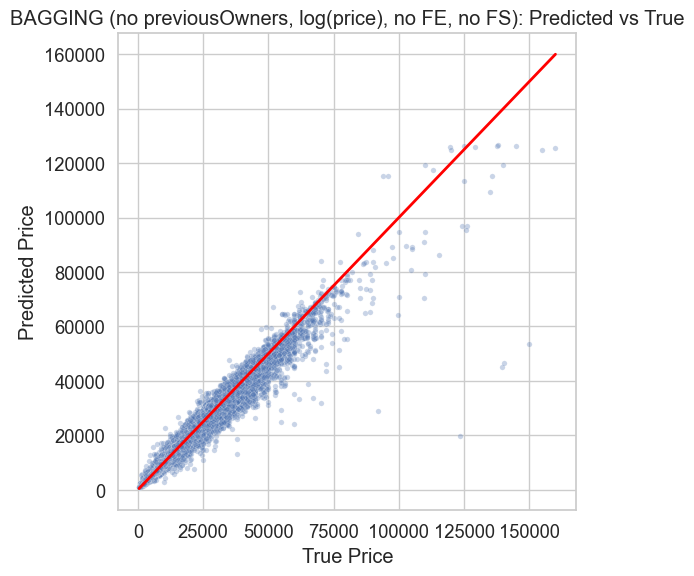

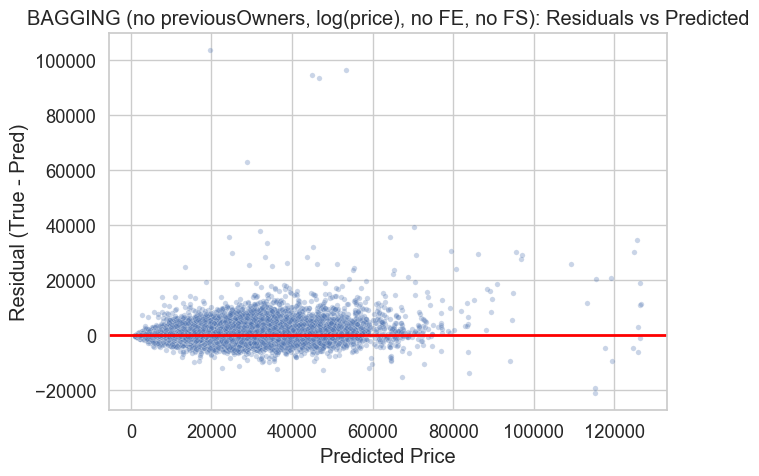

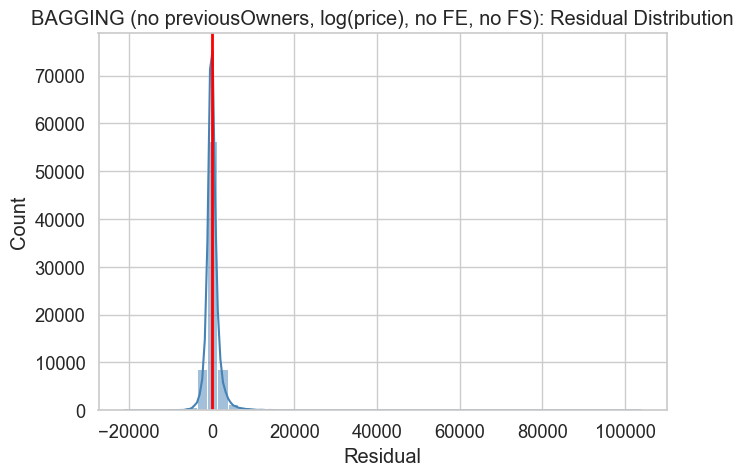

In [ ]:
# 1) Best config 
params = {
    'tree_min_samples_split': 10, 
    'tree_min_samples_leaf': 1, 
    'tree_max_depth': 20, 
    'n_estimators': 400, 
    'max_samples': 0.5, 
    'max_features': 0.9
}

MODEL_NAME = "BAGGING (no previousOwners, log(price), no FE, no FS)"


# 2) Build FULL training matrix for this setting
# (same logic as the CV loop, but fit on ALL data)
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]  # previousOwners excluded
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X_full = X.copy()
y_full = y.copy()

# ensure previousOwners never enters the pipeline
X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

# log target (train in log-space)
y_full_log = np.log1p(y_full)

# Preprocessing (fit on full data, transform on full data)
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full,
    valid_brands=valid_brands,
    brand_col="Brand",
    model_col="model",
    year_col="year",
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full,
    valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand",
    model_col="model",
    year_col="year",
    fuel_col="fuelType",
    mpg_col="mpg",
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full,
    valid_transmissions=valid_transmissions,
    transm_col="transmission",
    brand_col="Brand",
    model_col="model",
    fuel_col="fuelType",
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full,
    valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType",
    brand_col="Brand",
    model_col="model",
    transm_col="transmission",
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# Encoding (TE for Brand+model, OHE for the rest) 
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

# Numeric scaling 
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{c}" for c in numeric_features],
)

# final matrix used for training and for plots
X_full_sel = pd.concat([X_full_num_df, X_full_cat], axis=1)


# 3) Fit FINAL model on FULL data (log-space)
base_tree = DecisionTreeRegressor(
    max_depth=params["tree_max_depth"],
    min_samples_leaf=params["tree_min_samples_leaf"],
    min_samples_split=params["tree_min_samples_split"],
    random_state=RANDOM_STATE
)

model = BaggingRegressor(
    estimator=base_tree,
    n_estimators=params["n_estimators"],
    max_samples=params["max_samples"],
    max_features=params["max_features"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model
print("- training stacking (log-price)")
model.fit(X_full_sel, y_full_log)



# 4) Run ALL visualizations for this best model
plot_pred_vs_true_fs(model, MODEL_NAME)
plot_residuals_fs(model, MODEL_NAME)
plot_residual_distribution_fs(model, MODEL_NAME)

C:\Users\Rosa Melo\AppData\Local\Temp\ipykernel_30204\4128551160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


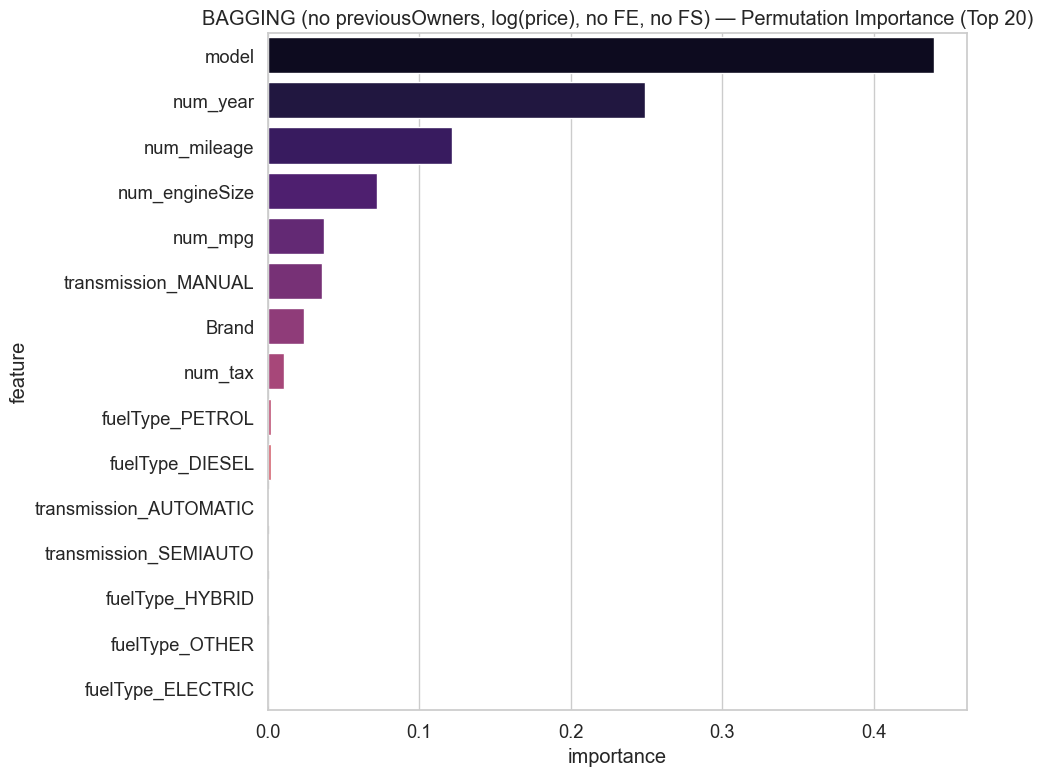

In [8]:
plot_permutation_importance_fs(model, MODEL_NAME, n_repeats=5, top=20)

In [11]:
split_freq_df = compute_split_frequency_fs(model)
display(split_freq_df.head(30))

,feature,split_count
8,num_year,192953
10,fuelType_HYBRID,187204
5,fuelType_DIESEL,183150
7,transmission_MANUAL,181619
3,num_engineSize,180528
2,num_mileage,180299
11,fuelType_ELECTRIC,173396
9,num_mpg,171433
6,Brand,165965
12,transmission_SEMIAUTO,160399


### 4.2. Results Obtained and Overall Performance Discussion <a id="results"></a>

 Our best model achieved an RMSE of approximately 2253 and a MAE of 1319 on validation data. This configuration was based on the basic model, no form of feature engineering or feature selection significantly improved the model's performance. This suggests that, at least in this case, the original features were already sufficiently informative to make the predictions.


 Across all experiments, we observed a consistent overfitting tendency, but it was moderate compared to what we would expect from decision trees alone. While decision trees are prone to overfitting, the bagging technique helped mitigate this effect. Despite this, there is still a noticeable gap between the training and validation errors, with the training data having consistently lower RMSE scores than the validation data.


From the previous plots and table we can get some important takeaways about the model's behaviour:

- Most of the data points in the *Predicted vs True* Price plot lie close to the diagonal, indicating that the model is reasonably accurate for many predictions. However, a noticeable number of points lie below the diagonal, meaning the model tends to underpredict, especially for higher-value cars. This suggests that while the model performs well overall, it systematically predicts lower prices than the true values in certain cases, particularly for very expensive vehicles.

- The *Residuals vs Predicted Price* scatter plot shows that the residuals are generally scattered around zero, indicating that the model is not biased, but there is more variance in the residuals for higher predicted prices, suggesting that the model is slightly more uncertain when predicting higher-priced cars, which could lead to larger residuals.

- The *Residual Distribution* histogram shows a long tail, especially on the positive side, indicating that there are some large errors in the predictions, suggesting that the model performs well in many cases but struggles with certain outliers, particularly for high-priced cars.

- Features with high importance directly influence the final output of the model, and the most important features for predicting car prices, such as `model`, `num_year`, `num_mileage`, and `num_engineSize`, are key drivers in the model's predictions.

- Features with the lowest split counts play a more significant role in splitting the data into meaningful subgroups. However, in this model, split count does not differ much between features (149k-193k).